# Pipeline

The following notebook contains the test of the clustering pipeline for the final algorithm

In [51]:
from ase import Atoms
from xtb.ase.calculator import XTB
# Import read from ase 
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [52]:
import re
from pathlib import Path
from typing import List, Tuple

from ase import Atoms
from ase.io import read


def read_structures_with_energies(xyz_path: str) -> Tuple[List[Atoms], List[float]]:
    """Read all structures with ASE and parse energies from the comment line."""
    path = Path(xyz_path)
    atoms_list = read(path.as_posix(), index=":")

    energies: List[float] = []
    with path.open("r", encoding="utf-8") as handle:
        while True:
            line = handle.readline()
            if not line:
                break
            natoms = int(line.strip())
            comment = handle.readline().strip()

            match = re.search(r"Energy:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", comment)
            energy = float(match.group(1)) if match else float("nan")
            energies.append(energy)

            for _ in range(natoms):
                handle.readline()

    for atoms, energy in zip(atoms_list, energies):
        atoms.info["energy"] = energy

    return atoms_list, energies

For the test i again use the water dimer and i used the initialization algorithm which randomly places the molecules using a sobol sequence and evaluates the energies using xtb. 

In [53]:
h2o_2_1000, energies_1000 = read_structures_with_energies("/media/storage_6/lme/master_thesis/cluster_generation/trajectories/initialization_trajectory_h2o_10000.xyz")
h2o_2_5000, energies_5000 = read_structures_with_energies("/media/storage_6/lme/master_thesis/cluster_generation/trajectories/initialization_trajectory_h2o_50000.xyz")
h2o_2_10000, energies_10000 = read_structures_with_energies("/media/storage_6/lme/master_thesis/cluster_generation/trajectories/initialization_trajectory_h2o_100000.xyz")
h2o_2_20000, energies_20000 = read_structures_with_energies("/media/storage_6/lme/master_thesis/cluster_generation/trajectories/initialization_trajectory_h2o_200000.xyz")
print(f"Read {len(h2o_2_1000)} structures with energies from 10000 configuration trajectory")
print(f"Read {len(h2o_2_5000)} structures with energies from 50000 configuration trajectory")
print(f"Read {len(h2o_2_10000)} structures with energies from 100000 configuration trajectory")
print(f"Read {len(h2o_2_20000)} structures with energies from 200000 configuration trajectory")

Read 1000 structures with energies from 10000 configuration trajectory
Read 5000 structures with energies from 50000 configuration trajectory
Read 10000 structures with energies from 100000 configuration trajectory
Read 20000 structures with energies from 200000 configuration trajectory


The following block contains the settings for the soap features

In [54]:
# SOAP feature config
from dscribe.descriptors import SOAP
r_cut = 6
n_max = 12
l_max = 8
sigma = 0.5
rbf = "gto"
average = "inner"

soap = SOAP(
    species=["H", "O"],
    periodic=False,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
    sigma=sigma,
    rbf=rbf,
    average=average,
)

In [55]:
import time
time_start = time.time()    
features_1000 = soap.create(h2o_2_1000)
time_end = time.time() 
print(f"Time taken to compute SOAP features for 1000 structures: {time_end - time_start:.2f} seconds") 
time_start = time.time() 
features_5000 = soap.create(h2o_2_5000)
time_end = time.time()
print(f"Time taken to compute SOAP features for 5000 structures: {time_end - time_start:.2f} seconds")
time_start = time.time()
features_10000 = soap.create(h2o_2_10000)
time_end = time.time()
print(f"Time taken to compute SOAP features for 10000 structures: {time_end - time_start:.2f} seconds")
time_start = time.time()
features_20000 = soap.create(h2o_2_20000)
time_end = time.time()
print(f"Time taken to compute SOAP features for 20000 structures: {time_end - time_start:.2f} seconds")


Time taken to compute SOAP features for 1000 structures: 0.40 seconds
Time taken to compute SOAP features for 5000 structures: 2.01 seconds
Time taken to compute SOAP features for 10000 structures: 3.92 seconds
Time taken to compute SOAP features for 20000 structures: 8.22 seconds


In [67]:
# Use spearman correlation to filter out highly correlated features with threshold of 0.95
from scipy.stats import spearmanr
def filter_correlated_features(features: np.ndarray, threshold: float = 0.95) -> np.ndarray:
    corr_matrix, _ = spearmanr(features)
    upper_tri = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    to_drop = set()
    for i in range(corr_matrix.shape[0]):
        for j in range(i + 1, corr_matrix.shape[0]):
            if abs(corr_matrix[i, j]) > threshold:
                to_drop.add(j)
    return features[:, sorted(set(range(features.shape[1])) - to_drop)]
features_1000_final = filter_correlated_features(features_1000)
features_5000_final = filter_correlated_features(features_5000)
features_10000_final = filter_correlated_features(features_10000)
features_20000_final = filter_correlated_features(features_20000)

print(f"Original number of features: {features_1000.shape[1]}, Filtered number of features: {features_1000_final.shape[1]}")

Original number of features: 2700, Filtered number of features: 747


In [56]:
from scipy.stats import zscore 
# Apply Z-Score normalization to the features to remove global outliers
z_scores_1000 = zscore(features_1000, axis=0)
z_scores_5000 = zscore(features_5000, axis=0)
z_scores_10000 = zscore(features_10000, axis=0)
z_scores_20000 = zscore(features_20000, axis=0)

outlier_mask_1000 = np.any(np.abs(z_scores_1000) > 3, axis=1)
outlier_mask_5000 = np.any(np.abs(z_scores_5000) > 3, axis=1)
outlier_mask_10000 = np.any(np.abs(z_scores_10000) > 3, axis=1)
outlier_mask_20000 = np.any(np.abs(z_scores_20000) > 3, axis=1)
print(f"Number of outliers in 1000 structures: {np.sum(outlier_mask_1000)}")
print(f"Number of outliers in 5000 structures: {np.sum(outlier_mask_5000)}")
print(f"Number of outliers in 10000 structures: {np.sum(outlier_mask_10000)}")
print(f"Number of outliers in 20000 structures: {np.sum(outlier_mask_20000)}")

# Remove outliers from the features and corresponding energies
features_1000_clean = features_1000[~outlier_mask_1000]
energies_1000_clean = np.array(energies_1000)[~outlier_mask_1000]
features_5000_clean = features_5000[~outlier_mask_5000]
energies_5000_clean = np.array(energies_5000)[~outlier_mask_5000]
features_10000_clean = features_10000[~outlier_mask_10000]
energies_10000_clean = np.array(energies_10000)[~outlier_mask_10000]
features_20000_clean = features_20000[~outlier_mask_20000]
energies_20000_clean = np.array(energies_20000)[~outlier_mask_20000]
print(f"Number of structures after outlier removal in 1000 structures: {features_1000_clean.shape[0]}")
print(f"Number of structures after outlier removal in 5000 structures: {features_5000_clean.shape[0]}")
print(f"Number of structures after outlier removal in 10000 structures: {features_10000_clean.shape[0]}")
print(f"Number of structures after outlier removal in 20000 structures: {features_20000_clean.shape[0]}")   

Number of outliers in 1000 structures: 566
Number of outliers in 5000 structures: 2954
Number of outliers in 10000 structures: 5858
Number of outliers in 20000 structures: 11635
Number of structures after outlier removal in 1000 structures: 434
Number of structures after outlier removal in 5000 structures: 2046
Number of structures after outlier removal in 10000 structures: 4142
Number of structures after outlier removal in 20000 structures: 8365


In [57]:
# Next perform isolation forest outlier detection with a contamination rate of 0.4
from sklearn.ensemble import IsolationForest

isolation_forest_1000 = IsolationForest(contamination=0.5, random_state=42)
isolation_forest_5000 = IsolationForest(contamination=0.5, random_state=42)
isolation_forest_10000 = IsolationForest(contamination=0.5, random_state=42)
isolation_forest_20000 = IsolationForest(contamination=0.5, random_state=42)
isolation_forest_1000.fit(features_1000_clean)
isolation_forest_5000.fit(features_5000_clean)
isolation_forest_10000.fit(features_10000_clean)
isolation_forest_20000.fit(features_20000_clean)
isolation_mask_1000 = isolation_forest_1000.predict(features_1000_clean) == 1
isolation_mask_5000 = isolation_forest_5000.predict(features_5000_clean) == 1
isolation_mask_10000 = isolation_forest_10000.predict(features_10000_clean) == 1
isolation_mask_20000 = isolation_forest_20000.predict(features_20000_clean) == 1
print(f"Number of outliers detected by isolation forest in 1000 structures: {np.sum(~isolation_mask_1000)}")
print(f"Number of outliers detected by isolation forest in 5000 structures: {np.sum(~isolation_mask_5000)}")
print(f"Number of outliers detected by isolation forest in 10000 structures: {np.sum(~isolation_mask_10000)}")
print(f"Number of outliers detected by isolation forest in 20000 structures: {np.sum(~isolation_mask_20000)}")
# Remove outliers detected by isolation forest
features_1000_final = features_1000_clean[isolation_mask_1000]
energies_1000_final = energies_1000_clean[isolation_mask_1000]
features_5000_final = features_5000_clean[isolation_mask_5000]
energies_5000_final = energies_5000_clean[isolation_mask_5000]
features_10000_final = features_10000_clean[isolation_mask_10000]
energies_10000_final = energies_10000_clean[isolation_mask_10000]
features_20000_final = features_20000_clean[isolation_mask_20000]
energies_20000_final = energies_20000_clean[isolation_mask_20000]
print(f"Number of structures after isolation forest outlier removal in 1000 structures: {features_1000_final.shape[0]}")
print(f"Number of structures after isolation forest outlier removal in 5000 structures: {features_5000_final.shape[0]}")
print(f"Number of structures after isolation forest outlier removal in 10000 structures: {features_10000_final.shape[0]}")
print(f"Number of structures after isolation forest outlier removal in 20000 structures: {features_20000_final.shape[0]}")

Number of outliers detected by isolation forest in 1000 structures: 217
Number of outliers detected by isolation forest in 5000 structures: 1023
Number of outliers detected by isolation forest in 10000 structures: 2071
Number of outliers detected by isolation forest in 20000 structures: 4182
Number of structures after isolation forest outlier removal in 1000 structures: 217
Number of structures after isolation forest outlier removal in 5000 structures: 1023
Number of structures after isolation forest outlier removal in 10000 structures: 2071
Number of structures after isolation forest outlier removal in 20000 structures: 4183


In [59]:
# Next compute a umap embedding to reduce to 10 dimensions
import umap
umap_1000 = umap.UMAP(n_components=10, random_state=42, n_neighbors=30, metric="manhattan")
umap_5000 = umap.UMAP(n_components=10, random_state=42, n_neighbors=30, metric="manhattan")
umap_10000 = umap.UMAP(n_components=10, random_state=42, n_neighbors=30, metric="manhattan")
umap_20000 = umap.UMAP(n_components=10, random_state=42, n_neighbors=30, metric="manhattan")
umap_1000_embedding = umap_1000.fit_transform(features_1000_final)
umap_5000_embedding = umap_5000.fit_transform(features_5000_final)
umap_10000_embedding = umap_10000.fit_transform(features_10000_final)
umap_20000_embedding = umap_20000.fit_transform(features_20000_final)

/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [60]:
# Finally use LocalOutlierFactor with a contamination of 0.3 on UMAP embeddings
from sklearn.neighbors import LocalOutlierFactor
lof_1000 = LocalOutlierFactor(contamination=0.3, metric="euclidean")
lof_5000 = LocalOutlierFactor(contamination=0.3, metric="euclidean")
lof_10000 = LocalOutlierFactor(contamination=0.3, metric="euclidean")
lof_20000 = LocalOutlierFactor(contamination=0.3, metric="euclidean")
lof_mask_1000 = lof_1000.fit_predict(umap_1000_embedding) == 1
lof_mask_5000 = lof_5000.fit_predict(umap_5000_embedding) == 1
lof_mask_10000 = lof_10000.fit_predict(umap_10000_embedding) == 1
lof_mask_20000 = lof_20000.fit_predict(umap_20000_embedding) == 1
print(f"Number of outliers detected by LocalOutlierFactor in 1000 structures: {np.sum(~lof_mask_1000)}")
print(f"Number of outliers detected by LocalOutlierFactor in 5000 structures: {np.sum(~lof_mask_5000)}")
print(f"Number of outliers detected by LocalOutlierFactor in 10000 structures: {np.sum(~lof_mask_10000)}")
print(f"Number of outliers detected by LocalOutlierFactor in 20000 structures: {np.sum(~lof_mask_20000)}")
# Remove outliers detected by LocalOutlierFactor from the original features
features_1000_final_lof = features_1000_final[lof_mask_1000]
energies_1000_final_lof = energies_1000_final[lof_mask_1000]
umap_1000_embedding_lof = umap_1000_embedding[lof_mask_1000]
features_5000_final_lof = features_5000_final[lof_mask_5000]
energies_5000_final_lof = energies_5000_final[lof_mask_5000]
umap_5000_embedding_lof = umap_5000_embedding[lof_mask_5000]
features_10000_final_lof = features_10000_final[lof_mask_10000]
energies_10000_final_lof = energies_10000_final[lof_mask_10000]
umap_10000_embedding_lof = umap_10000_embedding[lof_mask_10000]
features_20000_final_lof = features_20000_final[lof_mask_20000]
energies_20000_final_lof = energies_20000_final[lof_mask_20000]
umap_20000_embedding_lof = umap_20000_embedding[lof_mask_20000]
print(f"Number of structures after LocalOutlierFactor outlier removal in 1000 structures: {features_1000_final_lof.shape[0]}")
print(f"Number of structures after LocalOutlierFactor outlier removal in 5000 structures: {features_5000_final_lof.shape[0]}")
print(f"Number of structures after LocalOutlierFactor outlier removal in 10000 structures: {features_10000_final_lof.shape[0]}")
print(f"Number of structures after LocalOutlierFactor outlier removal in 20000 structures: {features_20000_final_lof.shape[0]}")

Number of outliers detected by LocalOutlierFactor in 1000 structures: 65
Number of outliers detected by LocalOutlierFactor in 5000 structures: 307
Number of outliers detected by LocalOutlierFactor in 10000 structures: 621
Number of outliers detected by LocalOutlierFactor in 20000 structures: 1255
Number of structures after LocalOutlierFactor outlier removal in 1000 structures: 152
Number of structures after LocalOutlierFactor outlier removal in 5000 structures: 716
Number of structures after LocalOutlierFactor outlier removal in 10000 structures: 1450
Number of structures after LocalOutlierFactor outlier removal in 20000 structures: 2928


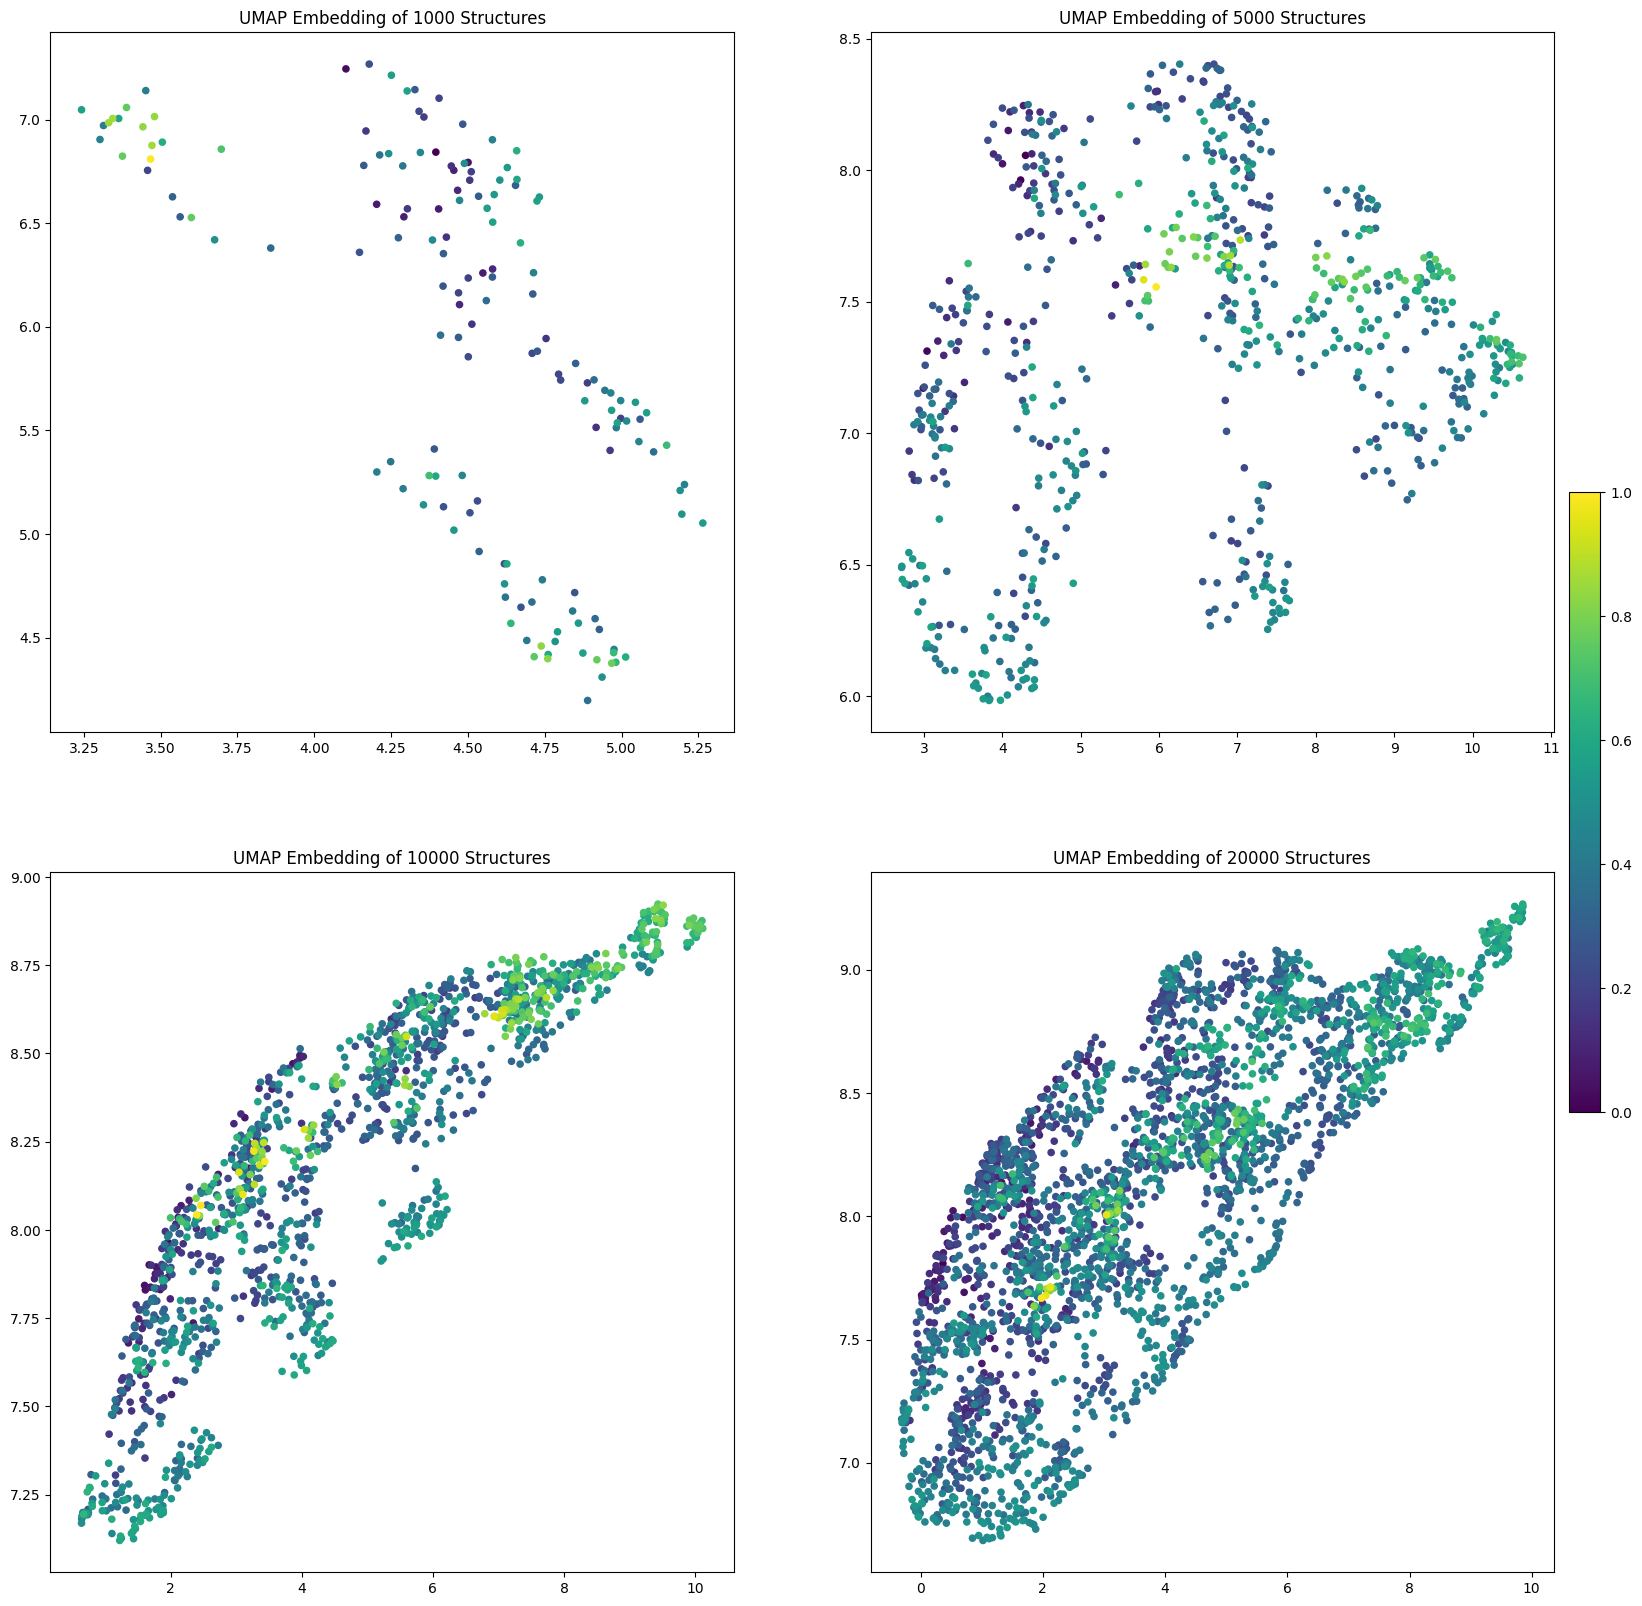

In [61]:
# Plot the first two dimensions of the umap embedding colored by energy
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes[0, 0].scatter(umap_1000_embedding_lof[:, 0], umap_1000_embedding_lof[:, 1], c=energies_1000_final_lof, cmap="viridis", s=20)
axes[0, 0].set_title("UMAP Embedding of 1000 Structures")
axes[0, 1].scatter(umap_5000_embedding_lof[:, 0], umap_5000_embedding_lof[:, 1], c=energies_5000_final_lof, cmap="viridis", s=20)
axes[0, 1].set_title("UMAP Embedding of 5000 Structures")
axes[1, 0].scatter(umap_10000_embedding_lof[:, 0], umap_10000_embedding_lof[:, 1], c=energies_10000_final_lof, cmap="viridis", s=20)
axes[1, 0].set_title("UMAP Embedding of 10000 Structures")
axes[1, 1].scatter(umap_20000_embedding_lof[:, 0], umap_20000_embedding_lof[:, 1], c=energies_20000_final_lof, cmap="viridis", s=20)
axes[1, 1].set_title("UMAP Embedding of 20000 Structures")
# Add colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="viridis"), ax=axes, orientation="vertical", fraction=0.02, pad=0.01)
plt.show()

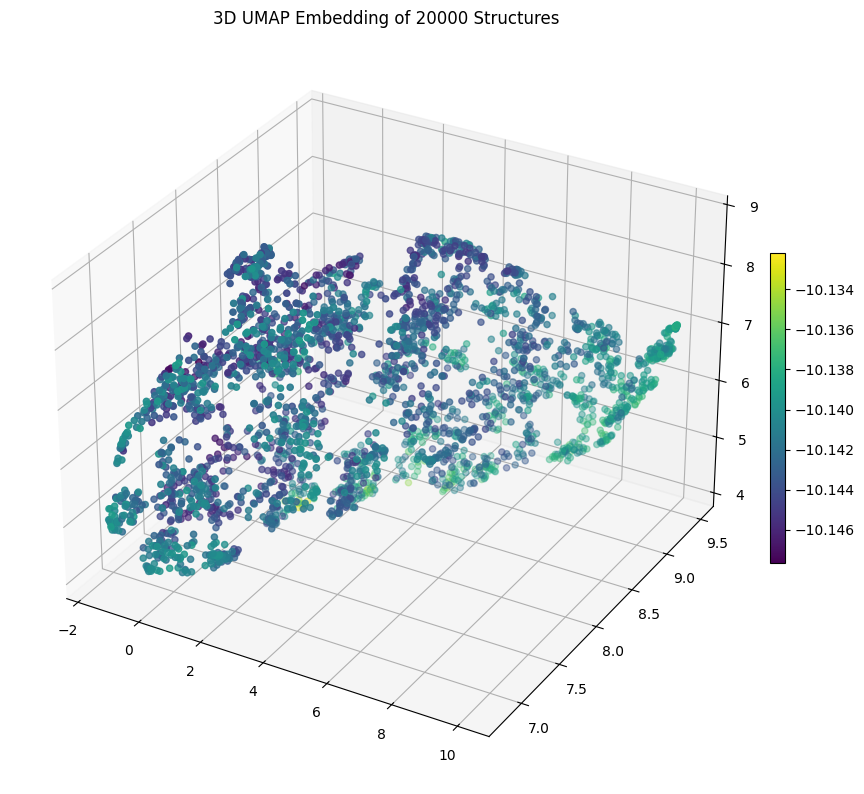

In [ ]:
# Plot 20000 structures in 3D colored by energy
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(umap_20000_embedding_lof[:, 0], umap_20000_embedding_lof[:, 1], umap_20000_embedding_lof[:, 2], c=energies_20000_final_lof, cmap="viridis", s=20)
ax.set_title("3D UMAP Embedding of 20000 Structures")
cbar = fig.colorbar(sc, orientation="vertical", fraction=0.02, pad=0.01)
plt.show()

In [ ]:
# Cluster with K-Means to obtain 5 clusters and retrieve the lowest energy structure from each cluster
from sklearn.cluster import KMeans
kmeans_1000 = KMeans(n_clusters=5, random_state=42)
kmeans_5000 = KMeans(n_clusters=5, random_state=42)
kmeans_10000 = KMeans(n_clusters=5, random_state=42)
kmeans_20000 = KMeans(n_clusters=5, random_state=42)
kmeans_1000.fit(umap_1000_embedding_lof)
kmeans_5000.fit(umap_5000_embedding_lof)
kmeans_10000.fit(umap_10000_embedding_lof)
kmeans_20000.fit(umap_20000_embedding_lof)
labels_1000 = kmeans_1000.labels_
labels_5000 = kmeans_5000.labels_
labels_10000 = kmeans_10000.labels_
labels_20000 = kmeans_20000.labels_
representative_structures_1000 = []
representative_structures_5000 = []
representative_structures_10000 = []
representative_structures_20000 = []
for i in range(5):
    cluster_indices_1000 = np.where(labels_1000 == i)[0]
    cluster_indices_5000 = np.where(labels_5000 == i)[0]
    cluster_indices_10000 = np.where(labels_10000 == i)[0]
    cluster_indices_20000 = np.where(labels_20000 == i)[0]
    if len(cluster_indices_1000) > 0:
        min_energy_index_1000 = cluster_indices_1000[np.argmin(energies_1000_final_lof[cluster_indices_1000])]
        representative_structures_1000.append(h2o_2_1000[min_energy_index_1000])
    if len(cluster_indices_5000) > 0:
        min_energy_index_5000 = cluster_indices_5000[np.argmin(energies_5000_final_lof[cluster_indices_5000])]
        representative_structures_5000.append(h2o_2_5000[min_energy_index_5000])
    if len(cluster_indices_10000) > 0:
        min_energy_index_10000 = cluster_indices_10000[np.argmin(energies_10000_final_lof[cluster_indices_10000])]
        representative_structures_10000.append(h2o_2_10000[min_energy_index_10000])
    if len(cluster_indices_20000) > 0:
        min_energy_index_20000 = cluster_indices_20000[np.argmin(energies_20000_final_lof[cluster_indices_20000])]
        representative_structures_20000.append(h2o_2_20000[min_energy_index_20000])
print(f"Representative structures from 1000 structures: {len(representative_structures_1000)}")
print(f"Representative structures from 5000 structures: {len(representative_structures_5000)}")
print(f"Representative structures from 10000 structures: {len(representative_structures_10000)}")
print(f"Representative structures from 20000 structures: {len(representative_structures_20000)}")

Representative structures from 1000 structures: 5
Representative structures from 5000 structures: 5
Representative structures from 10000 structures: 5
Representative structures from 20000 structures: 5


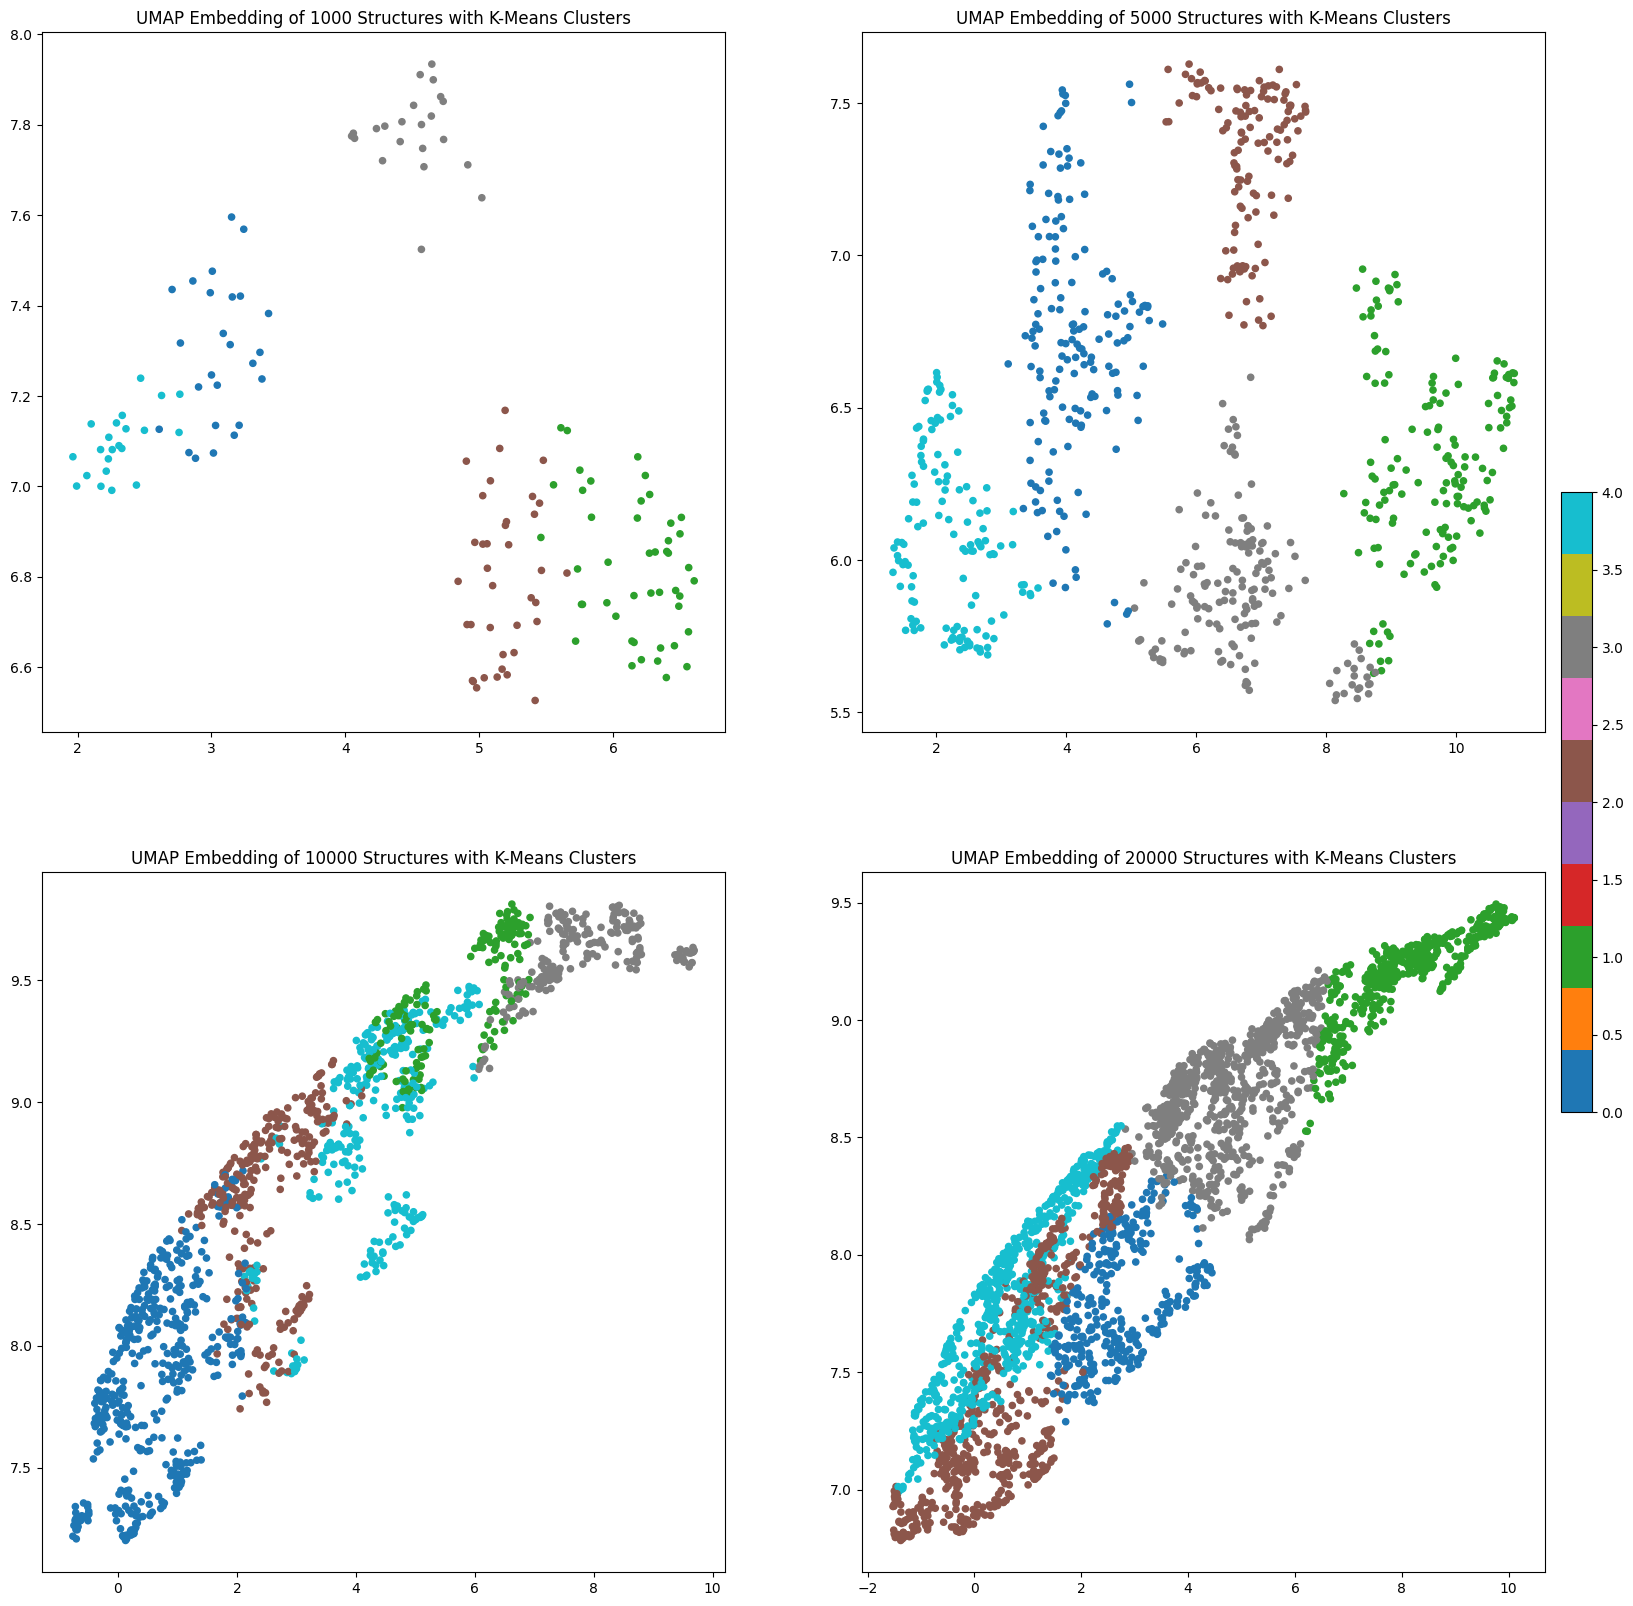

In [ ]:
# Plot all embeddings again with the clusters colored
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
scatter_1000 = axes[0, 0].scatter(umap_1000_embedding_lof[:, 0], umap_1000_embedding_lof[:, 1], c=labels_1000, cmap="tab10", s=20)
axes[0, 0].set_title("UMAP Embedding of 1000 Structures with K-Means Clusters")
scatter_5000 = axes[0, 1].scatter(umap_5000_embedding_lof[:, 0], umap_5000_embedding_lof[:, 1], c=labels_5000, cmap="tab10", s=20)
axes[0, 1].set_title("UMAP Embedding of 5000 Structures with K-Means Clusters")
scatter_10000 = axes[1, 0].scatter(umap_10000_embedding_lof[:, 0], umap_10000_embedding_lof[:, 1], c=labels_10000, cmap="tab10", s=20)
axes[1, 0].set_title("UMAP Embedding of 10000 Structures with K-Means Clusters")
scatter_20000 = axes[1, 1].scatter(umap_20000_embedding_lof[:, 0], umap_20000_embedding_lof[:, 1], c=labels_20000, cmap="tab10", s=20)
axes[1, 1].set_title("UMAP Embedding of 20000 Structures with K-Means Clusters")
# Add colorbar
cbar = fig.colorbar(scatter_1000, ax=axes, orientation="vertical", fraction=0.02, pad=0.01)
plt.show()

In [ ]:
# Finally try DBSCAN clustering with eps=0.5 and min_samples=10
from sklearn.cluster import DBSCAN
dbscan_1000 = DBSCAN(eps=0.01, min_samples=2*umap_1000_embedding_lof.shape[1])
dbscan_5000 = DBSCAN(eps=0.5, min_samples=2*umap_5000_embedding_lof.shape[1])
dbscan_10000 = DBSCAN(eps=0.5, min_samples=2*umap_10000_embedding_lof.shape[1])
dbscan_20000 = DBSCAN(eps=0.5, min_samples=2*umap_20000_embedding_lof.shape[1])
dbscan_1000.fit(umap_1000_embedding_lof)
dbscan_5000.fit(umap_5000_embedding_lof)
dbscan_10000.fit(umap_10000_embedding_lof)
dbscan_20000.fit(umap_20000_embedding_lof)
dbscan_labels_1000 = dbscan_1000.labels_
dbscan_labels_5000 = dbscan_5000.labels_
dbscan_labels_10000 = dbscan_10000.labels_
dbscan_labels_20000 = dbscan_20000.labels_
print(f"Number of clusters found by DBSCAN in 1000 structures: {len(set(dbscan_labels_1000)) - (1 if -1 in dbscan_labels_1000 else 0)}")
print(f"Number of clusters found by DBSCAN in 5000 structures: {len(set(dbscan_labels_5000)) - (1 if -1 in dbscan_labels_5000 else 0)}")
print(f"Number of clusters found by DBSCAN in 10000 structures: {len(set(dbscan_labels_10000)) - (1 if -1 in dbscan_labels_10000 else 0)}")
print(f"Number of clusters found by DBSCAN in 20000 structures: {len(set(dbscan_labels_20000)) - (1 if -1 in dbscan_labels_20000 else 0)}")

Number of clusters found by DBSCAN in 1000 structures: 0
Number of clusters found by DBSCAN in 5000 structures: 13
Number of clusters found by DBSCAN in 10000 structures: 26
Number of clusters found by DBSCAN in 20000 structures: 16


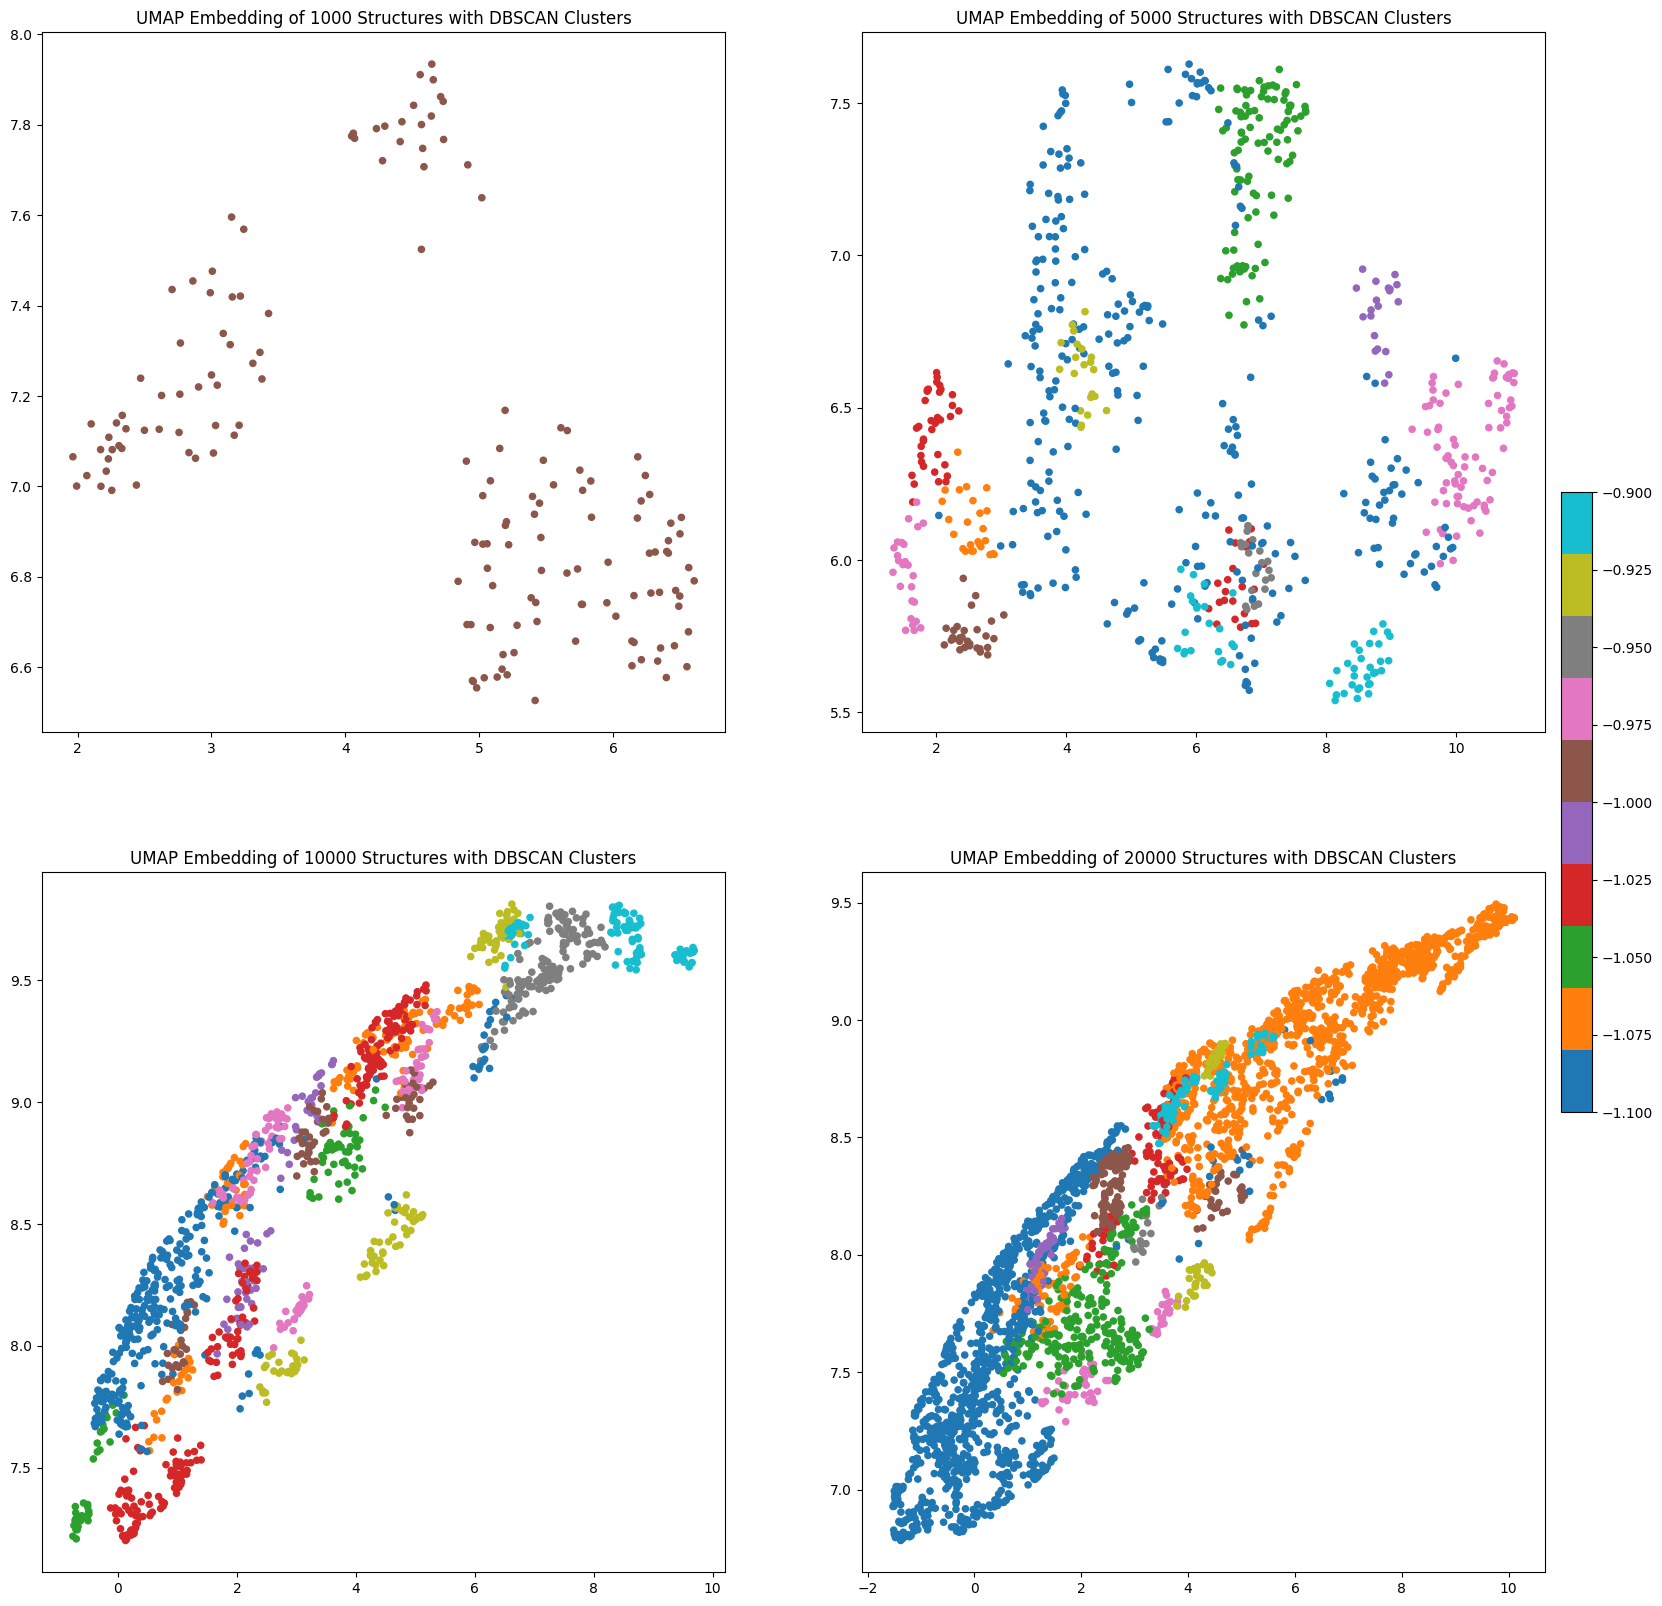

In [ ]:
# Plot with DBSCAN clusters colored
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
scatter_1000_dbscan = axes[0, 0].scatter(umap_1000_embedding_lof[:, 0], umap_1000_embedding_lof[:, 1], c=dbscan_labels_1000, cmap="tab10", s=20)
axes[0, 0].set_title("UMAP Embedding of 1000 Structures with DBSCAN Clusters")
scatter_5000_dbscan = axes[0, 1].scatter(umap_5000_embedding_lof[:, 0], umap_5000_embedding_lof[:, 1], c=dbscan_labels_5000, cmap="tab10", s=20)
axes[0, 1].set_title("UMAP Embedding of 5000 Structures with DBSCAN Clusters")
scatter_10000_dbscan = axes[1, 0].scatter(umap_10000_embedding_lof[:, 0], umap_10000_embedding_lof[:, 1], c=dbscan_labels_10000, cmap="tab10", s=20)
axes[1, 0].set_title("UMAP Embedding of 10000 Structures with DBSCAN Clusters")
scatter_20000_dbscan = axes[1, 1].scatter(umap_20000_embedding_lof[:, 0], umap_20000_embedding_lof[:, 1], c=dbscan_labels_20000, cmap="tab10", s=20)
axes[1, 1].set_title("UMAP Embedding of 20000 Structures with DBSCAN Clusters")
# Add colorbar
cbar = fig.colorbar(scatter_1000_dbscan, ax=axes, orientation="vertical", fraction=0.02, pad=0.01)
plt.show()

In [ ]:
# view the representative structures with ASE
from ase.visualize import view
view(representative_structures_1000[1], viewer="x3d")

In [ ]:
view(representative_structures_5000[4], viewer="x3d")

In [ ]:
view(representative_structures_10000[4], viewer="x3d")

# Metric Learning

One approach could be that we use metric learning to learn the distance metric for the umap embedding. 

In [62]:
import numpy as np
import umap
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [63]:
# 1) Choose train/test features from your pipeline
X_train = features_20000_final   # or features_20000_final_lof
X_test  = features_10000_final   # or features_10000_final_lof

# 2) Labels for training:
# Option A: true labels if available -> y_train = true_labels_20000
# Option B: pseudo-labels from clustering on train set
k = 5
kmeans_train = KMeans(n_clusters=k, random_state=42)
y_train = kmeans_train.fit_predict(X_train)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train labels:", np.bincount(y_train))

Train shape: (4183, 2700) Test shape: (2071, 2700)
Train labels: [ 733 1101 1049  563  737]


In [64]:
# 3) Supervised UMAP metric learning on train labels
mapper = umap.UMAP(
    n_neighbors=30,
    n_components=10,      # keep enough dimensions for downstream classification
    metric="manhattan",   # or "euclidean"/"cosine"
    random_state=42
).fit(X_train, y_train)

train_emb = mapper.embedding_
test_emb = mapper.transform(X_test)

print("Embedded train:", train_emb.shape, "Embedded test:", test_emb.shape)

/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedded train: (4183, 10) Embedded test: (2071, 10)


In [65]:
# 4) Train classifier in learned embedding and predict test
clf = KNeighborsClassifier(n_neighbors=15, weights="distance")
clf.fit(train_emb, y_train)
y_test_pred = clf.predict(test_emb)

print("Predicted test label counts:", np.bincount(y_test_pred))

Predicted test label counts: [376 620 461 241 373]


class 0: n=376, meanE=-10.1417, stdE=0.0026
class 1: n=620, meanE=-10.1416, stdE=0.0021
class 2: n=461, meanE=-10.1430, stdE=0.0019
class 3: n=241, meanE=-10.1401, stdE=0.0018
class 4: n=373, meanE=-10.1427, stdE=0.0022


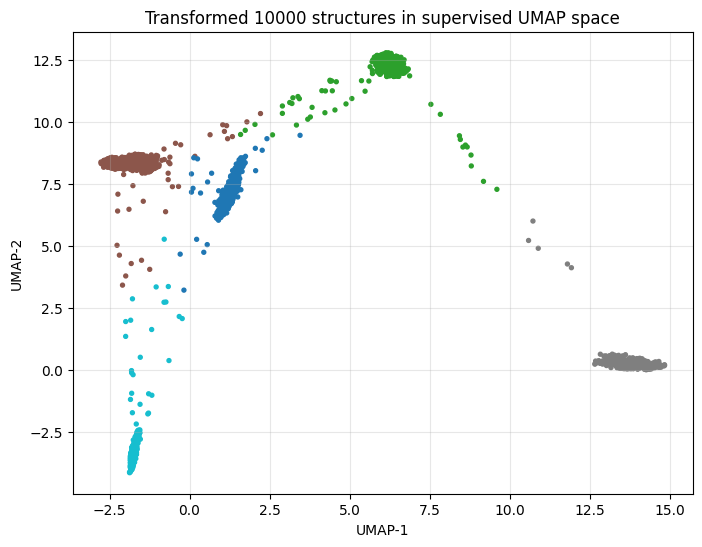

In [66]:
energies_test = energies_10000_final  # align with X_test choice above
for c in np.unique(y_test_pred):
    vals = np.array(energies_test)[y_test_pred == c]
    print(f"class {c}: n={len(vals)}, meanE={vals.mean():.4f}, stdE={vals.std():.4f}")

# quick 2D plot of transformed test
plt.figure(figsize=(8, 6))
plt.scatter(test_emb[:, 0], test_emb[:, 1], c=y_test_pred, s=8, cmap="tab10")
plt.title("Transformed 10000 structures in supervised UMAP space")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True, alpha=0.3)
plt.show()

# Test with the water trimer

In [ ]:
h2o_3_1000, energies_3_1000 = read_structures_with_energies("/media/storage_6/lme/master_thesis/cluster_generation/trajectories/initialization_trajectory_h2o3_1000.xyz")
h2o_3_5000, energies_3_5000 = read_structures_with_energies("/media/storage_6/lme/master_thesis/cluster_generation/trajectories/initialization_trajectory_h2o3_5000.xyz")
h2o_3_10000, energies_3_10000 = read_structures_with_energies("/media/storage_6/lme/master_thesis/cluster_generation/trajectories/initialization_trajectory_h2o3_10000.xyz")
h2o_3_20000, energies_3_20000 = read_structures_with_energies("/media/storage_6/lme/master_thesis/cluster_generation/trajectories/initialization_trajectory_h2o3_20000.xyz")
print(f"Read {len(h2o_3_1000)} structures with energies from 1000 configuration trajectory")
print(f"Read {len(h2o_3_5000)} structures with energies from 5000 configuration trajectory")
print(f"Read {len(h2o_3_10000)} structures with energies from 10000 configuration trajectory")
print(f"Read {len(h2o_3_20000)} structures with energies from 20000 configuration trajectory")

Read 1000 structures with energies from 1000 configuration trajectory
Read 5000 structures with energies from 5000 configuration trajectory
Read 10000 structures with energies from 10000 configuration trajectory
Read 20000 structures with energies from 20000 configuration trajectory


In [ ]:
# Compute SOAP features for the h2o_3 structures
time_start = time.time()
features_3_1000 = soap.create(h2o_3_1000)
time_end = time.time()
print(f"Time taken to compute SOAP features for 1000 structures: {time_end - time_start:.2f} seconds")
time_start = time.time()
features_3_5000 = soap.create(h2o_3_5000)
time_end = time.time()
print(f"Time taken to compute SOAP features for 5000 structures: {time_end - time_start:.2f} seconds")
time_start = time.time()
features_3_10000 = soap.create(h2o_3_10000)
time_end = time.time()
print(f"Time taken to compute SOAP features for 10000 structures: {time_end - time_start:.2f} seconds")
time_start = time.time()
features_3_20000 = soap.create(h2o_3_20000)
time_end = time.time()
print(f"Time taken to compute SOAP features for 20000 structures: {time_end - time_start:.2f} seconds")

Time taken to compute SOAP features for 1000 structures: 0.59 seconds
Time taken to compute SOAP features for 5000 structures: 2.78 seconds
Time taken to compute SOAP features for 10000 structures: 5.51 seconds
Time taken to compute SOAP features for 20000 structures: 11.32 seconds


In [ ]:
# Z-Score normalization for h2o_3 features
z_scores_3_1000 = zscore(features_3_1000, axis=0)
z_scores_3_5000 = zscore(features_3_5000, axis=0)
z_scores_3_10000 = zscore(features_3_10000, axis=0)
z_scores_3_20000 = zscore(features_3_20000, axis=0)
outlier_mask_3_1000 = np.any(np.abs(z_scores_3_1000) > 3, axis=1)
outlier_mask_3_5000 = np.any(np.abs(z_scores_3_5000) > 3, axis=1)
outlier_mask_3_10000 = np.any(np.abs(z_scores_3_10000) > 3, axis=1)
outlier_mask_3_20000 = np.any(np.abs(z_scores_3_20000) > 3, axis=1)
print(f"Number of outliers in 1000 structures: {np.sum(outlier_mask_3_1000)}")
print(f"Number of outliers in 5000 structures: {np.sum(outlier_mask_3_5000)}")
print(f"Number of outliers in 10000 structures: {np.sum(outlier_mask_3_10000)}")
print(f"Number of outliers in 20000 structures: {np.sum(outlier_mask_3_20000)}")
features_3_1000_clean = features_3_1000[~outlier_mask_3_1000]
energies_3_1000_clean = np.array(energies_3_1000)[~outlier_mask_3_1000]
features_3_5000_clean = features_3_5000[~outlier_mask_3_5000]
energies_3_5000_clean = np.array(energies_3_5000)[~outlier_mask_3_5000]
features_3_10000_clean = features_3_10000[~outlier_mask_3_10000]
energies_3_10000_clean = np.array(energies_3_10000)[~outlier_mask_3_10000]
features_3_20000_clean = features_3_20000[~outlier_mask_3_20000]
energies_3_20000_clean = np.array(energies_3_20000)[~outlier_mask_3_20000]
print(f"Number of structures after outlier removal in 1000 structures: {features_3_1000_clean.shape[0]}")
print(f"Number of structures after outlier removal in 5000 structures: {features_3_5000_clean.shape[0]}")
print(f"Number of structures after outlier removal in 10000 structures: {features_3_10000_clean.shape[0]}")
print(f"Number of structures after outlier removal in 20000 structures: {features_3_20000_clean.shape[0]}")
isolation_forest_3_1000 = IsolationForest(contamination=0.5, random_state=42)
isolation_forest_3_5000 = IsolationForest(contamination=0.5, random_state=42)
isolation_forest_3_10000 = IsolationForest(contamination=0.5, random_state=42)
isolation_forest_3_20000 = IsolationForest(contamination=0.5, random_state=42)
isolation_forest_3_1000.fit(features_3_1000_clean)
isolation_forest_3_5000.fit(features_3_5000_clean)
isolation_forest_3_10000.fit(features_3_10000_clean)
isolation_forest_3_20000.fit(features_3_20000_clean)
isolation_mask_3_1000 = isolation_forest_3_1000.predict(features_3_1000_clean) == 1
isolation_mask_3_5000 = isolation_forest_3_5000.predict(features_3_5000_clean) == 1
isolation_mask_3_10000 = isolation_forest_3_10000.predict(features_3_10000_clean) == 1
isolation_mask_3_20000 = isolation_forest_3_20000.predict(features_3_20000_clean) == 1
print(f"Number of outliers detected by isolation forest in 1000 structures: {np.sum(~isolation_mask_3_1000)}")
print(f"Number of outliers detected by isolation forest in 5000 structures: {np.sum(~isolation_mask_3_5000)}")
print(f"Number of outliers detected by isolation forest in 10000 structures: {np.sum(~isolation_mask_3_10000)}")
print(f"Number of outliers detected by isolation forest in 20000 structures: {np.sum(~isolation_mask_3_20000)}")
features_3_1000_final = features_3_1000_clean[isolation_mask_3_1000]
energies_3_1000_final = energies_3_1000_clean[isolation_mask_3_1000]
features_3_5000_final = features_3_5000_clean[isolation_mask_3_5000]
energies_3_5000_final = energies_3_5000_clean[isolation_mask_3_5000]
features_3_10000_final = features_3_10000_clean[isolation_mask_3_10000]
energies_3_10000_final = energies_3_10000_clean[isolation_mask_3_10000]
features_3_20000_final = features_3_20000_clean[isolation_mask_3_20000]
energies_3_20000_final = energies_3_20000_clean[isolation_mask_3_20000]
print(f"Number of structures after isolation forest outlier removal in 1000 structures: {features_3_1000_final.shape[0]}")     
print(f"Number of structures after isolation forest outlier removal in 5000 structures: {features_3_5000_final.shape[0]}")
print(f"Number of structures after isolation forest outlier removal in 10000 structures: {features_3_10000_final.shape[0]}")
print(f"Number of structures after isolation forest outlier removal in 20000 structures: {features_3_20000_final.shape[0]}")

Number of outliers in 1000 structures: 686
Number of outliers in 5000 structures: 3554
Number of outliers in 10000 structures: 7037
Number of outliers in 20000 structures: 14119
Number of structures after outlier removal in 1000 structures: 314
Number of structures after outlier removal in 5000 structures: 1446
Number of structures after outlier removal in 10000 structures: 2963
Number of structures after outlier removal in 20000 structures: 5881
Number of outliers detected by isolation forest in 1000 structures: 157
Number of outliers detected by isolation forest in 5000 structures: 723
Number of outliers detected by isolation forest in 10000 structures: 1481
Number of outliers detected by isolation forest in 20000 structures: 2940
Number of structures after isolation forest outlier removal in 1000 structures: 157
Number of structures after isolation forest outlier removal in 5000 structures: 723
Number of structures after isolation forest outlier removal in 10000 structures: 1482
Num

In [ ]:
# Perform UMAP embedding for h2o_3 structures
umap_3_1000 = umap.UMAP(n_components=10, random_state=42, n_neighbors=30)
umap_3_5000 = umap.UMAP(n_components=10, random_state=42, n_neighbors=30)
umap_3_10000 = umap.UMAP(n_components=10, random_state=42, n_neighbors=30)
umap_3_20000 = umap.UMAP(n_components=10, random_state=42, n_neighbors=30)
umap_3_1000_embedding = umap_3_1000.fit_transform(features_3_1000_final)
umap_3_5000_embedding = umap_3_5000.fit_transform(features_3_5000_final)
umap_3_10000_embedding = umap_3_10000.fit_transform(features_3_10000_final)
umap_3_20000_embedding = umap_3_20000.fit_transform(features_3_20000_final)

/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
# Finally use LocalOutlierFactor with a contamination of 0.3 on UMAP embeddings for h2o_3
lof_3_1000 = LocalOutlierFactor(contamination=0.3)
lof_3_5000 = LocalOutlierFactor(contamination=0.3)
lof_3_10000 = LocalOutlierFactor(contamination=0.3)
lof_3_20000 = LocalOutlierFactor(contamination=0.3)
lof_mask_3_1000 = lof_3_1000.fit_predict(umap_3_1000_embedding) == 1
lof_mask_3_5000 = lof_3_5000.fit_predict(umap_3_5000_embedding) == 1
lof_mask_3_10000 = lof_3_10000.fit_predict(umap_3_10000_embedding) == 1
lof_mask_3_20000 = lof_3_20000.fit_predict(umap_3_20000_embedding) == 1
print(f"Number of outliers detected by LocalOutlierFactor in 1000 structures: {np.sum(~lof_mask_3_1000)}")
print(f"Number of outliers detected by LocalOutlierFactor in 5000 structures: {np.sum(~lof_mask_3_5000)}")
print(f"Number of outliers detected by LocalOutlierFactor in 10000 structures: {np.sum(~lof_mask_3_10000)}")
print(f"Number of outliers detected by LocalOutlierFactor in 20000 structures: {np.sum(~lof_mask_3_20000)}")
features_3_1000_final_lof = features_3_1000_final[lof_mask_3_1000]
energies_3_1000_final_lof = energies_3_1000_final[lof_mask_3_1000]
umap_3_1000_embedding_lof = umap_3_1000_embedding[lof_mask_3_1000]
features_3_5000_final_lof = features_3_5000_final[lof_mask_3_5000]
energies_3_5000_final_lof = energies_3_5000_final[lof_mask_3_5000]
umap_3_5000_embedding_lof = umap_3_5000_embedding[lof_mask_3_5000]
features_3_10000_final_lof = features_3_10000_final[lof_mask_3_10000]
energies_3_10000_final_lof = energies_3_10000_final[lof_mask_3_10000]
umap_3_10000_embedding_lof = umap_3_10000_embedding[lof_mask_3_10000]
features_3_20000_final_lof = features_3_20000_final[lof_mask_3_20000]
energies_3_20000_final_lof = energies_3_20000_final[lof_mask_3_20000]
umap_3_20000_embedding_lof = umap_3_20000_embedding[lof_mask_3_20000]
print(f"Number of structures after LocalOutlierFactor outlier removal in 1000 structures: {features_3_1000_final_lof.shape[0]}")
print(f"Number of structures after LocalOutlierFactor outlier removal in 5000 structures: {features_3_5000_final_lof.shape[0]}")
print(f"Number of structures after LocalOutlierFactor outlier removal in 10000 structures: {features_3_10000_final_lof.shape[0]}")
print(f"Number of structures after LocalOutlierFactor outlier removal in 20000 structures: {features_3_20000_final_lof.shape[0]}")

Number of outliers detected by LocalOutlierFactor in 1000 structures: 47
Number of outliers detected by LocalOutlierFactor in 5000 structures: 217
Number of outliers detected by LocalOutlierFactor in 10000 structures: 445
Number of outliers detected by LocalOutlierFactor in 20000 structures: 882
Number of structures after LocalOutlierFactor outlier removal in 1000 structures: 110
Number of structures after LocalOutlierFactor outlier removal in 5000 structures: 506
Number of structures after LocalOutlierFactor outlier removal in 10000 structures: 1037
Number of structures after LocalOutlierFactor outlier removal in 20000 structures: 2059


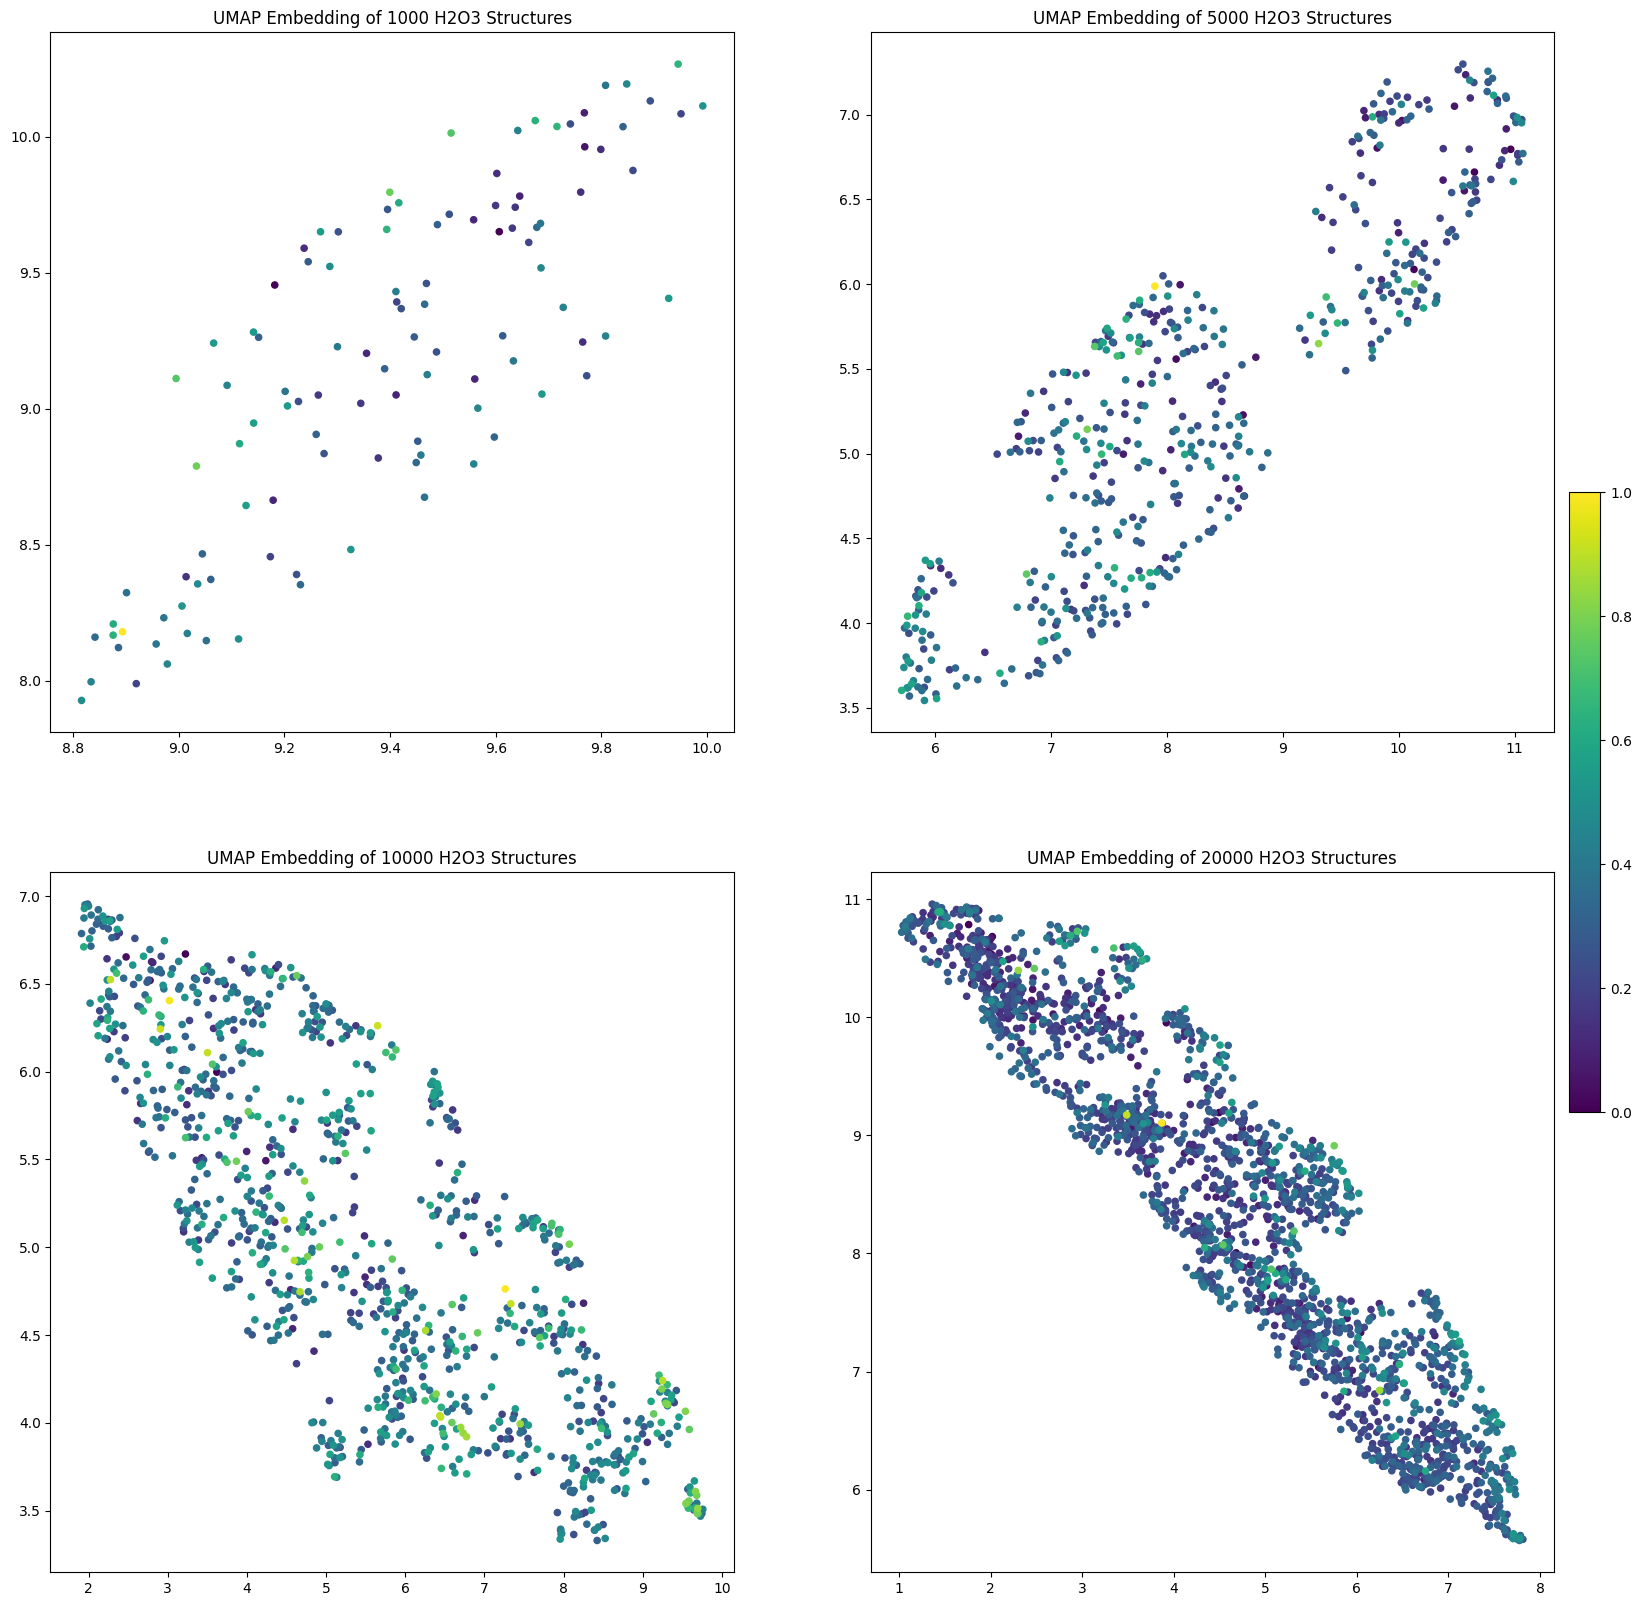

In [ ]:
# Plot the first two dimensions of the umap embedding colored by energy for h2o_3 structures
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes[0, 0].scatter(umap_3_1000_embedding_lof[:, 0], umap_3_1000_embedding_lof[:, 1], c=energies_3_1000_final_lof, cmap="viridis", s=20)
axes[0, 0].set_title("UMAP Embedding of 1000 H2O3 Structures")
axes[0, 1].scatter(umap_3_5000_embedding_lof[:, 0], umap_3_5000_embedding_lof[:, 1], c=energies_3_5000_final_lof, cmap="viridis", s=20)
axes[0, 1].set_title("UMAP Embedding of 5000 H2O3 Structures")
axes[1, 0].scatter(umap_3_10000_embedding_lof[:, 0], umap_3_10000_embedding_lof[:, 1], c=energies_3_10000_final_lof, cmap="viridis", s=20)
axes[1, 0].set_title("UMAP Embedding of 10000 H2O3 Structures")
axes[1, 1].scatter(umap_3_20000_embedding_lof[:, 0], umap_3_20000_embedding_lof[:, 1], c=energies_3_20000_final_lof, cmap="viridis", s=20)
axes[1, 1].set_title("UMAP Embedding of 20000 H2O3 Structures")
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="viridis"), ax=axes, orientation="vertical", fraction=0.02, pad=0.01)    
plt.show()

In [ ]:
# Cluster with K-Means to obtain 5 clusters and retrieve the lowest energy structure from each cluster for h2o_3 structures
kmeans_3_1000 = KMeans(n_clusters=5, random_state=42)
kmeans_3_5000 = KMeans(n_clusters=5, random_state=42)
kmeans_3_10000 = KMeans(n_clusters=5, random_state=42)
kmeans_3_20000 = KMeans(n_clusters=5, random_state=42)
kmeans_3_1000.fit(umap_3_1000_embedding_lof)
kmeans_3_5000.fit(umap_3_5000_embedding_lof)
kmeans_3_10000.fit(umap_3_10000_embedding_lof)
kmeans_3_20000.fit(umap_3_20000_embedding_lof)
labels_3_1000 = kmeans_3_1000.labels_
labels_3_5000 = kmeans_3_5000.labels_
labels_3_10000 = kmeans_3_10000.labels_
labels_3_20000 = kmeans_3_20000.labels_
representative_structures_3_1000 = []
representative_structures_3_5000 = []
representative_structures_3_10000 = []
representative_structures_3_20000 = []
for i in range(5):
    cluster_indices_3_1000 = np.where(labels_3_1000 == i)[0]
    cluster_indices_3_5000 = np.where(labels_3_5000 == i)[0]
    cluster_indices_3_10000 = np.where(labels_3_10000 == i)[0]
    cluster_indices_3_20000 = np.where(labels_3_20000 == i)[0]
    if len(cluster_indices_3_1000) > 0:
        min_energy_index_3_1000 = cluster_indices_3_1000[np.argmin(energies_3_1000_final_lof[cluster_indices_3_1000])]
        representative_structures_3_1000.append(h2o_3_1000[min_energy_index_3_1000])
    if len(cluster_indices_3_5000) > 0:
        min_energy_index_3_5000 = cluster_indices_3_5000[np.argmin(energies_3_5000_final_lof[cluster_indices_3_5000])]
        representative_structures_3_5000.append(h2o_3_5000[min_energy_index_3_5000])
    if len(cluster_indices_3_10000) > 0:
        min_energy_index_3_10000 = cluster_indices_3_10000[np.argmin(energies_3_10000_final_lof[cluster_indices_3_10000])]
        representative_structures_3_10000.append(h2o_3_10000[min_energy_index_3_10000])
    if len(cluster_indices_3_20000) > 0:
        min_energy_index_3_20000 = cluster_indices_3_20000[np.argmin(energies_3_20000_final_lof[cluster_indices_3_20000])]
        representative_structures_3_20000.append(h2o_3_20000[min_energy_index_3_20000])
print(f"Representative structures from 1000 H2O3 structures: {len(representative_structures_3_1000)}")
print(f"Representative structures from 5000 H2O3 structures: {len(representative_structures_3_5000)}")
print(f"Representative structures from 10000 H2O3 structures: {len(representative_structures_3_10000)}")
print(f"Representative structures from 20000 H2O3 structures: {len(representative_structures_3_20000)}")

Representative structures from 1000 H2O3 structures: 5
Representative structures from 5000 H2O3 structures: 5
Representative structures from 10000 H2O3 structures: 5
Representative structures from 20000 H2O3 structures: 5


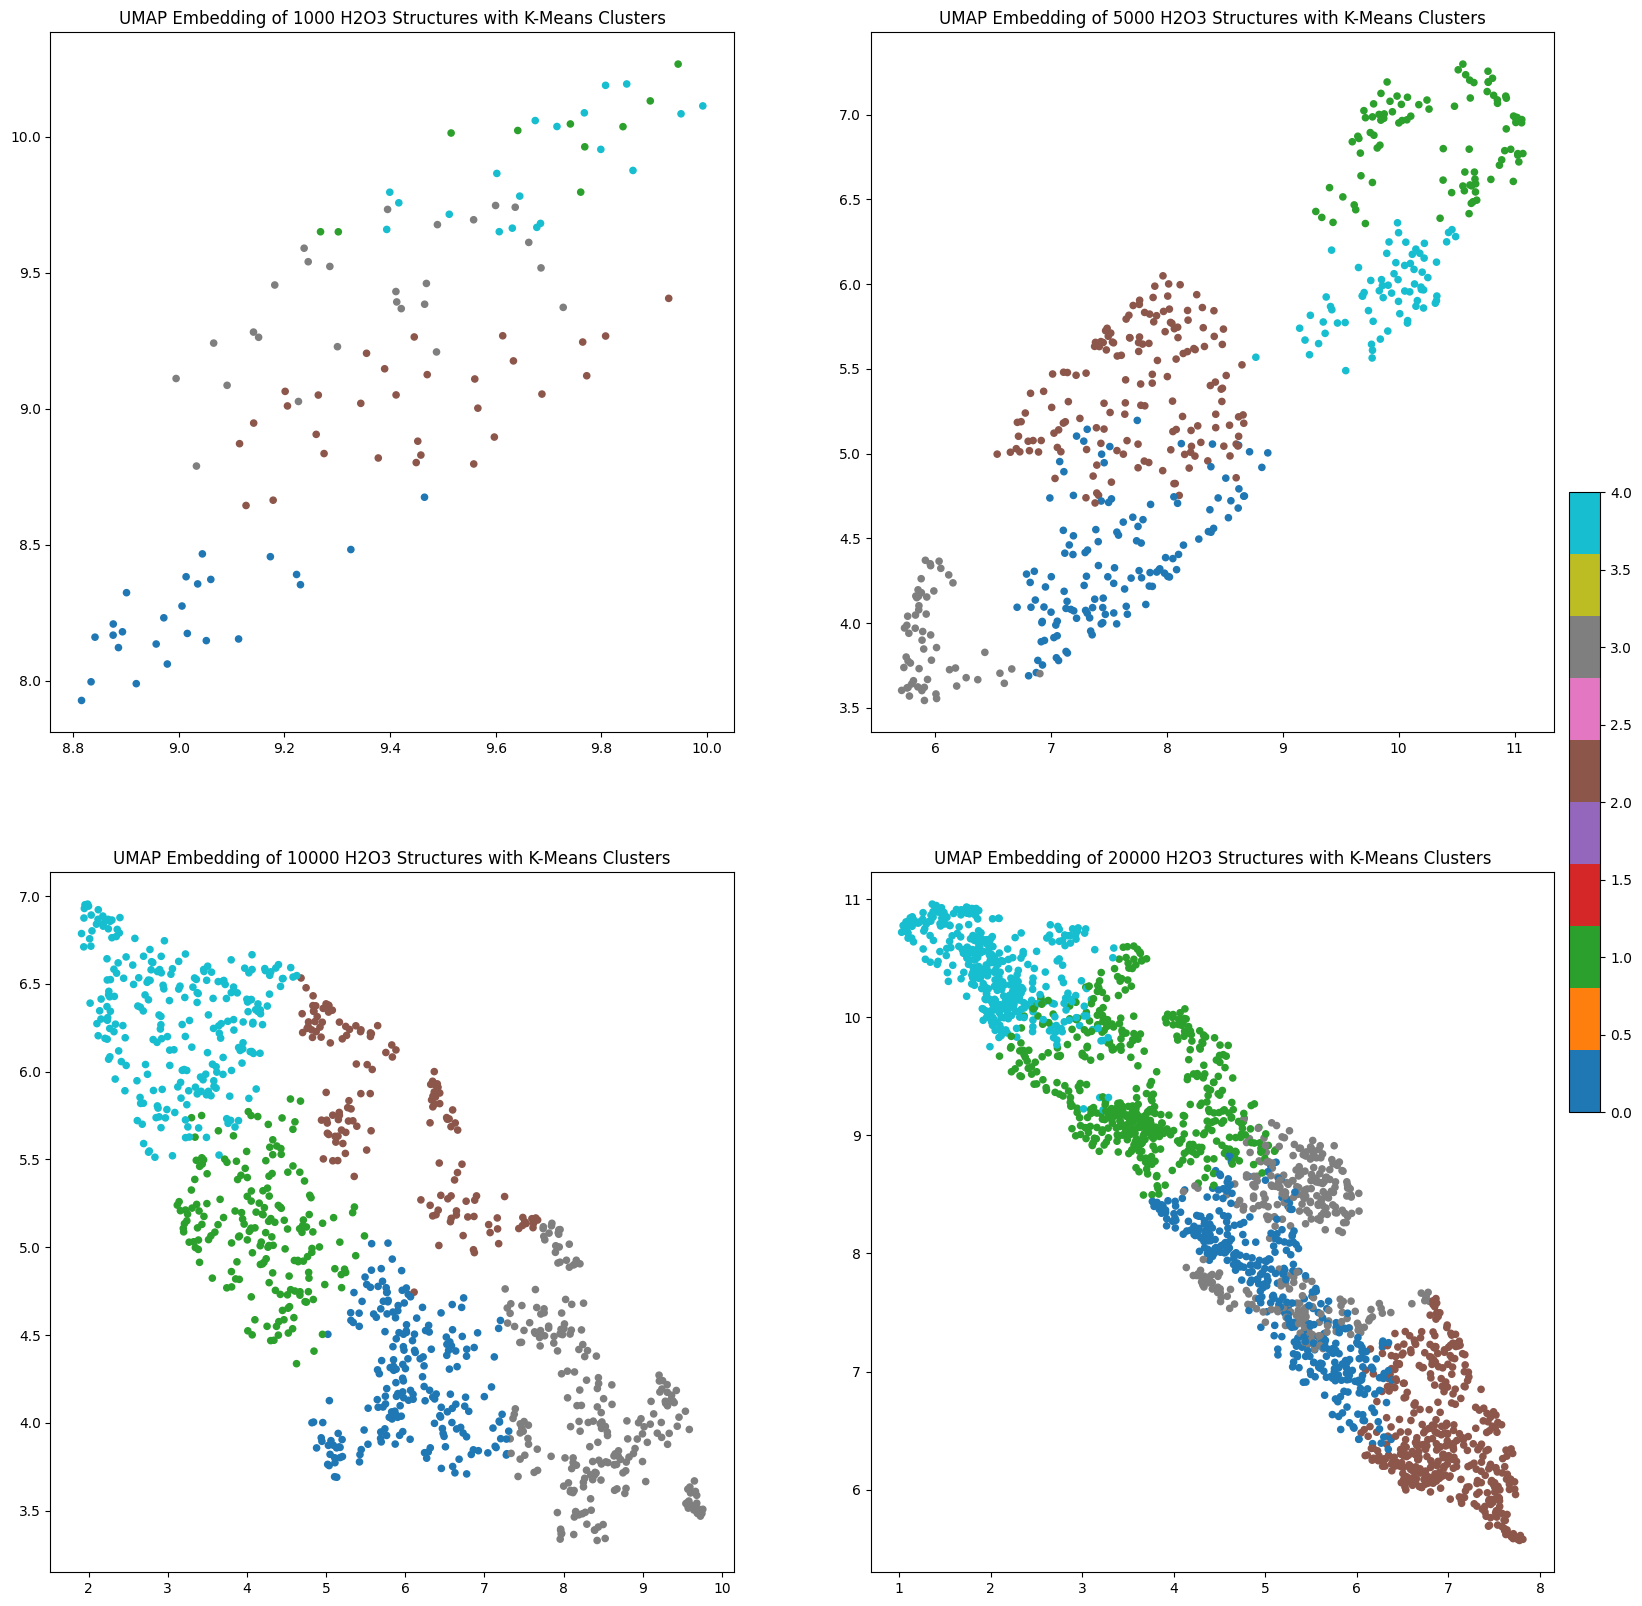

In [ ]:
# Plot embeddings with K-Means clusters colored for h2o_3 structures
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
scatter_3_1000 = axes[0, 0].scatter(umap_3_1000_embedding_lof[:, 0], umap_3_1000_embedding_lof[:, 1], c=labels_3_1000, cmap="tab10", s=20)
axes[0, 0].set_title("UMAP Embedding of 1000 H2O3 Structures with K-Means Clusters")
scatter_3_5000 = axes[0, 1].scatter(umap_3_5000_embedding_lof[:, 0], umap_3_5000_embedding_lof[:, 1], c=labels_3_5000, cmap="tab10", s=20)
axes[0, 1].set_title("UMAP Embedding of 5000 H2O3 Structures with K-Means Clusters")
scatter_3_10000 = axes[1, 0].scatter(umap_3_10000_embedding_lof[:, 0], umap_3_10000_embedding_lof[:, 1], c=labels_3_10000, cmap="tab10", s=20)
axes[1, 0].set_title("UMAP Embedding of 10000 H2O3 Structures with K-Means Clusters")
scatter_3_20000 = axes[1, 1].scatter(umap_3_20000_embedding_lof[:, 0], umap_3_20000_embedding_lof[:, 1], c=labels_3_20000, cmap="tab10", s=20)
axes[1, 1].set_title("UMAP Embedding of 20000 H2O3 Structures with K-Means Clusters")
cbar = fig.colorbar(scatter_3_1000, ax=axes, orientation="vertical", fraction=0.02, pad=0.01)    
plt.show()

In [ ]:
view(representative_structures_3_1000[2], viewer="x3d")

In [ ]:
view(representative_structures_3_5000[2], viewer="x3d")

In [ ]:
view(representative_structures_3_10000[3], viewer="x3d")

In [ ]:
view(representative_structures_3_20000[3], viewer="x3d")